In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))
from scipy.optimize import curve_fit
from scipy import stats
import pandas as pd

# Load simulation outputs

In [2]:
files = os.listdir("../toy/output/")
#print(files)

outputs = ["toy/output/" + item for item in files if ".npz" in item]
print(outputs)

['toy/output/tau_160s_theta_22_axial_10.0mK_transv_5.0mK_p_2.npz', 'toy/output/tau_20s_theta_22_axial_15.0mK_transv_20.0mK_p_2.npz', 'toy/output/tau_80s_theta_45_axial_5.0mK_transv_20.0mK_p_2.npz', 'toy/output/tau_40s_theta_45_axial_20.0mK_transv_15.0mK_p_2.npz', 'toy/output/tau_25s_theta_20_axial_4.0mK_transv_6.0mK_p_2.npz', 'toy/output/tau_40s_theta_22_axial_10.0mK_transv_15.0mK_p_2.npz', 'toy/output/tau_40s_theta_90_axial_5.0mK_transv_20.0mK_p_2.npz', 'toy/output/tau_160s_theta_90_axial_5.0mK_transv_15.0mK_p_2.npz', 'toy/output/tau_30s_theta_20_axial_4.0mK_transv_5.0mK_p_2.npz', 'toy/output/tau_25s_theta_14_axial_5.0mK_transv_8.0mK_p_2.npz', 'toy/output/tau_120s_theta_90_axial_5.0mK_transv_10.0mK_p_2.npz', 'toy/output/tau_80s_theta_180_axial_15.0mK_transv_10.0mK_p_2.npz', 'toy/output/tau_25s_theta_20_axial_5.0mK_transv_4.0mK_p_2.npz', 'toy/output/tau_35s_theta_14_axial_5.0mK_transv_4.0mK_p_2.npz', 'toy/output/tau_160s_theta_180_axial_15.0mK_transv_10.0mK_p_2.npz', 'toy/output/tau_35

In [3]:
from v1.Utils import ReadTheCsv,ReadTheSpill,append_to_dict

## Z cuts

In [4]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b, cuts):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a
        self.CutsType = cuts

ZCUTS = Zcuts(-415,-671, CutsType)

# Define the analysis functions for data and simulation

In [5]:
def analysis_function(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    Time_Annihilation = Time_Annihilation[np.isfinite(Time_Annihilation)]
    counts, edges = np.histogram(Time_Annihilation, bins = 50, range = (0,398.1), density = False)
    return Time_Annihilation, counts, edges

def analysis_data(file, Zcuts):
    # read the file
    dataset = ReadTheCsv(file, "-1", Zcuts.zmin, Zcuts.zmax, ZCUTS.CutsType)
    # Three Segment Ramp Down
    start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(file,"\"MBMF RampDown\"[0]")
    start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(file,"\"MBMF RampDown\"[1]")
    start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(file,"\"MBMF RampDown\"[2]")

    # print(f"{start_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]} ")
    # print(f"{start_mbmf_rampdown1[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown1[0] - start_mbmf_rampdown1[0]} ")
    # print(f"{start_mbmf_rampdown2[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown2[0] - start_mbmf_rampdown2[0]} ")
    mask      = ((dataset[CutsType] == 1) & 
                (dataset["Z"] > ZCUTS.zmin) & 
                (dataset["Z"] < ZCUTS.zmax))
    mask_time = ((dataset["run time"] > start_mbmf_rampdown0[0]) & 
                 (dataset["run time"] < start_mbmf_rampdown0[0] + 398.1))

    Event_Distribution = dataset["run time"][mask & mask_time].to_numpy() - start_mbmf_rampdown0[0]
    X_distribution = dataset["X"][mask & mask_time].to_numpy()
    Y_distribution = dataset["Y"][mask & mask_time].to_numpy()
    Z_distribution = dataset["Z"][mask & mask_time].to_numpy()

    counts, edges = np.histogram(Event_Distribution, bins = 50, range = (0,398.1), density = False)
    
    return Event_Distribution, counts, edges

# Main Loop for Kolmogorov Test and visualization

In [6]:
!ls

Comparison.ipynb  simulation_results.png


In [7]:
list_dataset = ["v1/ag14100/ag14100.vertex.csv",
                "v1/ag14106/ag14106.vertex.csv",
                "v1/ag14268/ag14268.vertex.csv",
                "v1/ag14286/ag14286.vertex.csv",
                "v1/ag14308/ag14308.vertex.csv"]

best_for_dataset = []

for dataset in list_dataset:
    best_sim    = ""
    best_LR     = 1e6
    best_pvalue = 0.0

    # read the dataset
    Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    
    for file in outputs:
        Time_Simulation, counts_sim, edges_sim =  analysis_function("../" + file)

        obs = Event_Distribution # time cut of the simulation :(
        sim = Time_Simulation

        counts_sim = counts_sim * counts_obs.sum() / counts_sim.sum()
        
        LR, pvalue_lr = stats.power_divergence(counts_obs, counts_sim, lambda_="log-likelihood")
        print(f"LR statistic = {LR:.4}/{(len(counts_obs) - 1)}")
        print(f"p-value      = {pvalue_lr}")

        if(LR < best_LR):
            best_sim = file
            best_pvalue = pvalue_lr
            best_LR = LR
            stringa = f"Best LR: {LR:.5}/49, pvalue = {pvalue_lr:.4}"
        
        print(f"best pvalue {best_pvalue}")
        print(f"best LR {best_LR}")
        print("-"*16)
    
    best_for_dataset.append((best_sim, stringa))

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

KS statistic = 0.4745730994152047
p-value      = 5.840380765870828e-82
LR statistic = inf/49
p-value      = 0.0
best pvalue 0.0
best LR 1000000.0
----------------
KS statistic = 0.4869635627530364
p-value      = 1.6588461632939487e-98
LR statistic = inf/49
p-value      = 0.0
best pvalue 0.0
best LR 1000000.0
----------------
KS statistic = 0.38379544662180387
p-value      = 9.0279697396003e-58


/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)
/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: invalid value encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


KS statistic = 0.4797749853295291
p-value      = 2.6601624739228944e-90
LR statistic = 1.17e+03/49
p-value      = 7.683875067595964e-213
best pvalue 1.0522438886050827e-43
best LR 332.12324382666986
----------------
KS statistic = 0.29692037444689034
p-value      = 1.9937403026385265e-32
LR statistic = 559.4/49
p-value      = 9.137697717101927e-88
best pvalue 1.0522438886050827e-43
best LR 332.12324382666986
----------------
KS statistic = 0.45555091957905336
p-value      = 7.899741691145775e-82
LR statistic = 1.194e+03/49
p-value      = 8.803879962840827e-218
best pvalue 1.0522438886050827e-43
best LR 332.12324382666986
----------------
KS statistic = 0.45493584708038753
p-value      = 5.290257018837946e-84
LR statistic = inf/49
p-value      = 0.0
best pvalue 1.0522438886050827e-43
best LR 332.12324382666986
----------------
KS statistic = 0.47791944461229613
p-value      = 8.866366786672948e-90
LR statistic = inf/49
p-value      = 0.0
best pvalue 1.0522438886050827e-43
best LR 332.12

/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


KS statistic = 0.33224827845416594
p-value      = 1.5251261840462796e-42
LR statistic = 680.3/49
p-value      = 5.104888502858783e-112
best pvalue 4.719124747584793e-45
best LR 339.3349337625217
----------------
KS statistic = 0.28389195935104294
p-value      = 1.2902008612705282e-29
LR statistic = 457.9/49
p-value      = 9.119718608111676e-68
best pvalue 4.719124747584793e-45
best LR 339.3349337625217
----------------
KS statistic = 0.5379408936137031
p-value      = 2.950003573880703e-116
LR statistic = inf/49
p-value      = 0.0
best pvalue 4.719124747584793e-45
best LR 339.3349337625217
----------------
KS statistic = 0.45505540662585836
p-value      = 2.1220431807416594e-78
LR statistic = 965.6/49
p-value      = 2.081268712753196e-170
best pvalue 4.719124747584793e-45
best LR 339.3349337625217
----------------
KS statistic = 0.32300034705097996
p-value      = 1.3599774567166291e-34
LR statistic = inf/49
p-value      = 0.0
best pvalue 4.719124747584793e-45
best LR 339.3349337625217
-

...

KS statistic = 0.38097134144564976
p-value      = 4.155825117516835e-59
LR statistic = 1.018e+03/49
p-value      = 2.5163840359676897e-181
best pvalue 9.505248862070472e-49
best LR 358.98348366221614
----------------
KS statistic = 0.45681807685794773
p-value      = 1.4081993616354136e-83
LR statistic = 1.131e+03/49
p-value      = 1.1894365447244054e-204
best pvalue 9.505248862070472e-49
best LR 358.98348366221614
----------------
KS statistic = 0.41131887083598073
p-value      = 8.923078688943809e-69
LR statistic = 1.097e+03/49
p-value      = 1.0353801805148563e-197
best pvalue 9.505248862070472e-49
best LR 358.98348366221614
----------------
KS statistic = 0.24221264524575856
p-value      = 1.0838784172264348e-21
LR statistic = 395.8/49
p-value      = 9.592728655693582e-56
best pvalue 9.505248862070472e-49
best LR 358.98348366221614
----------------
KS statistic = 0.28259924454119584
p-value      = 1.7913021959739896e-28
LR statistic = 559.8/49
p-value      = 7.694823728791241e-88
be

/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)
/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: invalid value encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


KS statistic = 0.4160341813522699
p-value      = 6.7710008874755085e-43
LR statistic = 440.8/49
p-value      = 2.0085381338362167e-64
best pvalue 9.687716500419793e-24
best LR 221.2649865636593
----------------
KS statistic = 0.5067980279667239
p-value      = 1.083351372386044e-64
LR statistic = inf/49
p-value      = 0.0
best pvalue 9.687716500419793e-24
best LR 221.2649865636593
----------------
KS statistic = 0.674957279178915
p-value      = 1.8843130046970273e-120
LR statistic = inf/49
p-value      = 0.0
best pvalue 9.687716500419793e-24
best LR 221.2649865636593
----------------
KS statistic = 0.45336481044299404
p-value      = 7.768291587332931e-51
LR statistic = 532.2/49
p-value      = 2.3093023389799064e-82
best pvalue 9.687716500419793e-24
best LR 221.2649865636593
----------------
KS statistic = 0.5266753655619925
p-value      = 1.5697181597153267e-66
LR statistic = 917.8/49
p-value      = 1.4788967004089012e-160
best pvalue 9.687716500419793e-24
best LR 221.2649865636593
----

/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)
/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: invalid value encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


KS statistic = 0.24782312757809105
p-value      = 1.4875993234401202e-21
LR statistic = 366.1/49
p-value      = 4.362121875515836e-50
best pvalue 7.733804443482503e-27
best LR 239.1443291217921
----------------
KS statistic = 0.2914350602468755
p-value      = 9.362423266592063e-29
LR statistic = nan/49
p-value      = nan
best pvalue 7.733804443482503e-27
best LR 239.1443291217921
----------------
KS statistic = 0.4460020926224206
p-value      = 6.64635040681382e-75
LR statistic = 961.0/49
p-value      = 1.8398808398395207e-169
best pvalue 7.733804443482503e-27
best LR 239.1443291217921
----------------
KS statistic = 0.2631636698455711
p-value      = 1.1933027806905534e-24
LR statistic = 478.0/49
p-value      = 1.101861669584006e-71
best pvalue 7.733804443482503e-27
best LR 239.1443291217921
----------------
KS statistic = 0.4217571271657163
p-value      = 2.3893901848907364e-67
LR statistic = 900.7/49
p-value      = 5.0910497408003417e-157
best pvalue 7.733804443482503e-27
best LR 239

[('toy/output/tau_20s_theta_25_axial_4.0mK_transv_4.0mK_p_2.npz', 'Best LR: 207.51/49, pvalue = 2.117e-21'), ('toy/output/tau_15s_theta_20_axial_4.0mK_transv_4.0mK_p_2.npz', 'Best LR: 213.6/49, pvalue = 1.972e-22'), ('toy/output/tau_20s_theta_20_axial_4.0mK_transv_6.0mK_p_2.npz', 'Best LR: 304.26/49, pvalue = 1.531e-38'), ('toy/output/tau_20s_theta_25_axial_4.0mK_transv_4.0mK_p_2.npz', 'Best LR: 162.11/49, pvalue = 5.02e-14'), ('toy/output/tau_20s_theta_20_axial_4.0mK_transv_6.0mK_p_2.npz', 'Best LR: 123.97/49, pvalue = 1.991e-08')]
 v1/ag14100/ag14100.vertex.csv, ('toy/output/tau_20s_theta_25_axial_4.0mK_transv_4.0mK_p_2.npz', 'Best LR: 207.51/49, pvalue = 2.117e-21')
../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148     

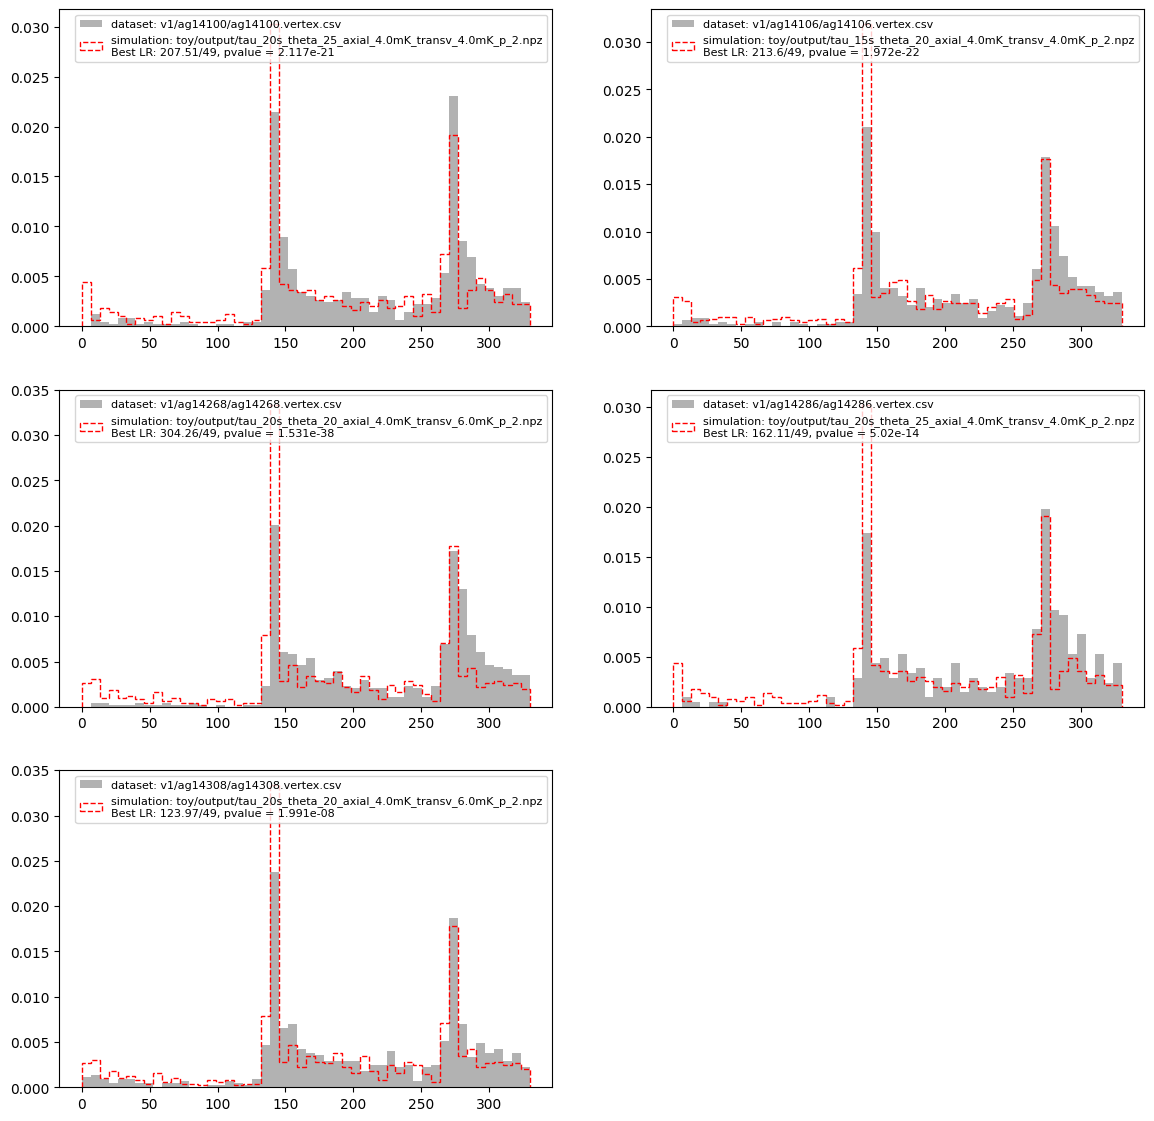

In [8]:
plt.figure(0, figsize = (14,14))

print(best_for_dataset)
#best_for_dataset[0] = ("toy/output/tau_120s_theta_22_axial_5.0mK_transv_15.0mK_p_2.npz",0.1)

i = 1
for dataset,simulation in zip(list_dataset, best_for_dataset):
    plt.subplot(3,2,i)
    i += 1
    print(f" {dataset}, {simulation}")
    
    Time_Simulation, counts, edges =  analysis_function("../" + simulation[0])
    Event_Distribution, counts, edges = analysis_data( "../" + dataset, ZCUTS)

    plt.hist(Event_Distribution, bins = 50, range = (0,330), density = True, color = "black", alpha = .3, label = f"dataset: {dataset}")
    plt.hist(Time_Simulation, bins = 50, range = (0,330), density = True, linestyle = "--", histtype = "step" ,color = "red", label = f"simulation: {simulation[0]}\n" +  simulation[1])
    plt.legend(fontsize = 8)
plt.savefig("simulation_results.png", bbox_inches = 'tight')